# Clustering and Genres

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alexsosn/ugarit-dh-workshop/blob/main/notebooks/2b_similarity_clustering.ipynb) [![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/alexsosn/ugarit-dh-workshop/main?labpath=notebooks%2F2b_similarity_clustering.ipynb)


We turn every tablet into a vector of its vocabulary, project all of them onto a 2-D map, and colour by genre.

## Setup


In [17]:
# === SETUP — run me first ===
import os, sys, subprocess, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "2")

if "google.colab" in sys.modules:                      # we're on Colab
    REPO_URL = "https://github.com/alexsosn/ugarit-dh-workshop.git"
    REPO_DIR = "/content/ugarit-dh-workshop"
    if not os.path.isdir(REPO_DIR):                    # clone the repo once
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(os.path.join(REPO_DIR, "notebooks"))      # work from notebooks/
    # Colab already ships numpy/pandas/scikit-learn/matplotlib/plotly/networkx;
    # pyarrow for parquet support
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "umap-learn", "pyarrow"], check=False)

# make data/loader.py importable (we run from the notebooks/ folder)
sys.path.insert(0, os.path.abspath(".."))

Let's load the texts and see what's inside each text object.

In [18]:
from data.loader import load_texts

texts = load_texts()     # Downloads/caches the CUC HuggingFace parquet if needed
print(f"Loaded {len(texts)} tablets — genre of the first one: {texts[0]['genre']}")
list(texts[0].keys())

[loader] Loaded 279 CUC tablets, 26086 word tokens (source: AlexWalhai/CUC parquet cache, licence: CC BY-NC 4.0).
Loaded 279 tablets — genre of the first one: myth


['ktu',
 'title',
 'name',
 'genre',
 'language',
 'lines',
 'ugaritic',
 'refs',
 'tokens',
 'source']

## What genres CUC has?

CUC uses KTU genre convention:

- **1.** literary and religious texts
- **2.** letters
- **3.** legal texts
- **4.** economic or administrative texts
- **5.** scribal exercises
- **6.** inscriptions on seals, labels, ivories, etc.
- **7.** unclassified texts
- **8.** illegible tablets and uninscribed fragments
- **9.** unpublished texts

In [19]:
# Select only texts with at least 30 tokens for clustering
sample = [t for t in texts if len(t["tokens"]) >= 30]

# What's the genre of each of the selected texts?
genres = [t["genre"] for t in sample]

print(f"Selected {len(sample)} tablets with at least 30 tokens.")
print(f"Genres: {set(genres)}")

Selected 166 tablets with at least 30 tokens.
Genres: {'literary/religious', 'god-list', 'letter', 'epic', 'ritual', 'divination', 'legal/economic', 'myth'}


### Genre balance of the mapped tablets

Before the map: *how many* tablets of each genre are we actually projecting? The classes are **imbalanced** (letters dominate) — worth remembering when reading how tight or sparse each colour's cluster looks.

In [20]:
import pandas as pd, plotly.express as px
from collections import Counter
gd = pd.Series(Counter(genres)).sort_values()
fig = px.bar(x=gd.values, y=gd.index, orientation="h", text=gd.values,
             color=gd.index, title="Genre balance of the mapped tablets")
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False,
                  xaxis_title="tablets", yaxis_title="",
                  margin=dict(l=120, r=30, t=50, b=30),
                  paper_bgcolor="white", plot_bgcolor="white")
fig.show()

In [21]:
from data.loader import corpus_as_documents
labels, docs = corpus_as_documents(sample)
print(labels[:10])  # print the first 10 labels
print(docs[:5])  # print the first 5 documents

['1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.14', '1.15', '1.16']
['ḥšk ʿṣk ʿbṣk ʿmy pʿnk tlsmn ʿmy twtḥ išdk tk ḫršnr tḥmk w št l ẓr rdyk iqnim yšu b qrb asr tm ymtm npšh w iṯl ḥršm ʿdb l arṣ špm ʿdb tʿtqn šb ilk in bb b alp ḥẓr l pʿn ʿnt yhbr w yql yštḥwyn w y kbdnh yšu gh w yṣḥ tḥm ṯr il abk hwt lṯpn ḥtkk qryy b arṣ mlḥmt št b ʿp rm ddym sk šlm l kbd arṣ arbdd l kbd šdm ḥšk ʿṣk ʿbṣk ʿmy pʿnk tlsmn ʿmy twtḥ išdk tk ḫršn bdk spr ymnk kptr ksu ṯbth ḥkpt arṣ nḥlth b alp šd rbt kmn l pʿn kṯr hbr w ql tštḥwy w kbd hwt w rgm l kṯr w ḫss ṯny l hyn d ḥrš ydm tḥm ṯr il ab hwt lṯpn ḥtk yh kṯr bn št l skt n ʿdb b ġrt ṯbt ḥšqk ʿṣk ʿbṣk ʿmy pʿnk tlsmn ʿmy tkwtḥ išdk tk ḫršn ġr ks dm rgm iṯ ly w argmk hwt wṯaṯnyk rgm ʿṣ w lḫšt abn tunt šmm ʿm arṣ thmt ʿmn kbkbm rgm l tdʿ nšm w l tbn hmlt arṣ at w ank ibġyh w yʿn kṯr w ḫss lk lk ʿnn ilm atm bštm w an šnt b kptr l rḥq ilm ḥkpt l rḥq ilnym ṯn mṯpdm tḥt ʿnt arṣ ṯlṯ mtḥ ġyrm idk l ytn pnm ʿm lṭpn il d pid tk ḫršn ġr ks ygly ḏd il w ybu qrš mlk 

## What are the most common words?

The most common words in any language are so-called "stop-words": prepositions, conjunctions, and other small lexemes.

In [22]:
from data.loader import token_counts
token_counts(sample).most_common(15)

[('w', 1617),
 ('l', 1253),
 ('b', 859),
 ('bʿl', 319),
 ('il', 300),
 ('k', 271),
 ('bn', 239),
 ('mlk', 235),
 ('ilm', 204),
 ('š', 190),
 ('ym', 172),
 ('d', 168),
 ('bt', 161),
 ('ʿl', 132),
 ('u', 131)]

## Turn each tablet into a TF-IDF vector
Convert the sample of texts into a bag-of-words representation using TF-IDF. Each tablet becomes a point in a high-dimensional 'vocabulary space'.


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
vec = TfidfVectorizer(token_pattern=r"[^\s]+")
X = vec.fit_transform(docs).toarray()
print(f"{X.shape[0]} tablets in a {X.shape[1]}-word space")

166 tablets in a 5000-word space


Visualize TF-IDF matrix

In [24]:
X[:10, :10]

array([[0.        , 0.        , 0.        , 0.05838287, 0.        ,
        0.        , 0.        , 0.02919144, 0.03554388, 0.        ],
       [0.        , 0.        , 0.01300311, 0.04143052, 0.        ,
        0.01839143, 0.        , 0.04143052, 0.0336309 , 0.        ],
       [0.        , 0.        , 0.        , 0.01412713, 0.        ,
        0.        , 0.        , 0.0423814 , 0.        , 0.        ],
       [0.        , 0.        , 0.00948552, 0.01007426, 0.        ,
        0.        , 0.        , 0.02014852, 0.        , 0.        ],
       [0.        , 0.        , 0.04125332, 0.02190689, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.01294057, 0.01374375, 0.        ,
        0.        , 0.        , 0.        , 0.03346915, 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.0120153

/var/folders/36/tkl6h9x94x59nd7b7rwpxrd00000gp/T/ipykernel_97751/2900537478.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(X), aspect='auto', cmap='gray')


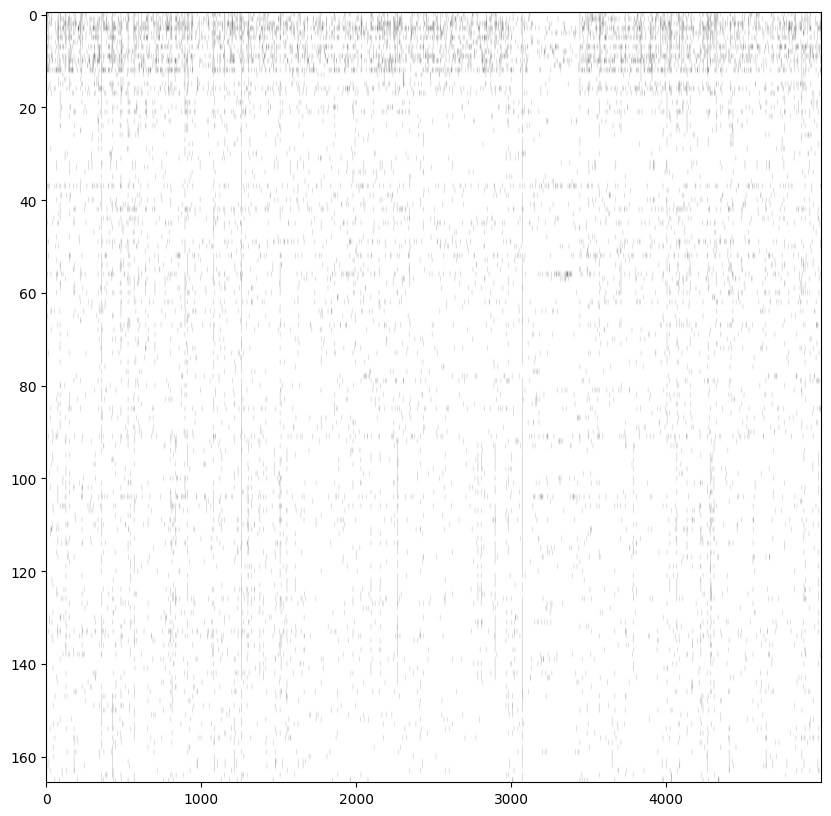

In [25]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
plt.imshow(np.log(X), aspect='auto', cmap='gray')

## TF-IDF Explained

Let's plot a hystogram of TF-IDF.

12762 non-zero TF-IDF values out of 830000


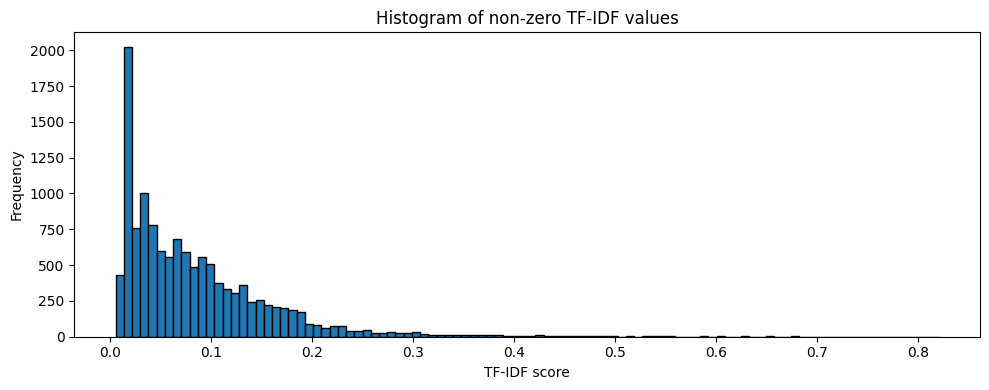

In [26]:
nonzero = X[X > 0]
print(f"{nonzero.size} non-zero TF-IDF values out of {X.size}")

plt.figure(figsize=(10, 4))
plt.hist(nonzero, bins=100, edgecolor="black")
plt.title("Histogram of non-zero TF-IDF values")
plt.xlabel("TF-IDF score")
plt.ylabel("Frequency")
plt.tight_layout()

## Top keywords per tablet

In [27]:
import numpy as np
feat = np.array(vec.get_feature_names_out())

def top_kw(i, n=6):
    row = X[i].ravel()
    idx = row.argsort()[::-1][:n]
    return [feat[j] for j in idx if row[j] > 0]

for i in np.random.choice(len(sample), 10, replace=False):
    t = sample[i]
    print(f'{t["ktu"]:7s} [{t["genre"]:11s}] {top_kw(i)}')

1.166   [literary/religious] ['ʿṯb', 'ʿẓrn', 'ʿẓrnm', 'tddn', 'maḫr', 'bdrš']
2.87    [letter     ] ['w', 'mrṣ', 'd', 'npšk', 'ly', 'lby']
1.50    [literary/religious] ['ʿṯtrt', 'w', 'ṯṯ', 'ʿṣr', 'l', 'kmm']
1.179   [literary/religious] ['kbkb', 'w', 'b', 'thm', 'abn', 'bʿl']
1.15    [epic       ] ['krt', 'tld', 'ḫbr', 'pġt', 'tšʿrb', 'ḥry']
2.16    [letter     ] ['umy', 'pn', 'twḥln', 'mab', 'ʿtn', 'špš']
3.30    [legal/economic] ['ksp', 'ʿl', 'šlmy', 'bn', 'arbʿm', 'ṯṯm']
1.94    [literary/religious] ['qdš', 'ybšr', 'w', 'šnx', 'bxn', 'pṯ']
1.117   [literary/religious] ['pdry', 'ryt', 'ṭlm', 'aṣṣ', 'lkw', 'arx']
1.101   [literary/religious] ['xxxxxxxxš', 'rišh', 'ydh', 'b', 'ġr', 'k']


## Top keywords per genre (UDB)

The UDB labels every tablet with an editor-chosen genre, so we can ask a question: what vocabulary is characteristic of each genre? We'll treat each UDB genre as one document and rank its words by TF-IDF — a word scores high when it is frequent in this genre but rare across the others.

- **Administrative** →  numerals and commodities: `šd` (field);
- **Correspondence** → the letter formula `l … rgm … tḥm … šlm` ("to … say … message of … greetings");
- **Myth** → divine names `bʿl, il, ym`;
- **Ritual** → offering terms `š` (sheep), `gdlt` (cow).

FIXME: ??? The ubiquitous particles `w, l, b` surface in *every* genre — that is TF-IDF telling you they carry no genre signal. ???

In [28]:
# === Characteristic keywords per UDB genre ===
# Needs the local UDB parquet (built from your own PDF):
#     python -m workshop_tools.build_udb_parquet
from data.udb_loader import udb_available, udb_tablet_corpus

if not udb_available():
    print("UDB parquet not built — skipping the UDB keywords.\n"
          "Build it from your own PDF:  python -m workshop_tools.build_udb_parquet")
else:
    udb = udb_tablet_corpus("00")
    udb = udb[udb["genre"].notna() & (udb["n_tokens"] > 0)].copy()
    udb["doc"] = udb["tokens"].map(" ".join)
    by_genre = udb.groupby("genre")["doc"].apply(" ".join)   # one document per genre
    vec_g = TfidfVectorizer(token_pattern=r"[^\s]+")
    Xg = vec_g.fit_transform(by_genre.values)
    feat_g = np.array(vec_g.get_feature_names_out())
    counts_g = udb["genre"].value_counts()
    print("Top TF-IDF keywords per UDB genre (each genre = one document):\n")
    for i, g in enumerate(by_genre.index):
        row = Xg[i].toarray().ravel()
        top = [feat_g[j] for j in row.argsort()[::-1][:10] if row[j] > 0]
        print(f"{g:16s} (n={counts_g[g]:4d})  {', '.join(top)}")

Top TF-IDF keywords per UDB genre (each genre = one document):

Administrative   (n= 783)  bn, 1, w, b, 2, l, šd, 3, ṯlṯ, ʿšr
Correspondence   (n=  81)  w, l, mlk, rgm, bʿly, ank, b, tḥm, šlm, ʿm
Epic             (n=   6)  w, b, l, krt, k, il, aqht, dnil, ġzr, bʿl
Legal            (n=  12)  w, bn, l, b, ksp, mlk, mit, nqmd, unṯ, hnd
Myth             (n=  58)  w, l, b, bʿl, il, k, ilm, arṣ, aliyn, ym
Ritual           (n=  84)  w, l, š, b, ulp, il, gdlt, bʿl, nḥš, mlk


## Squash that space down to 2 dimensions
**UMAP** keeps similar tablets near each other. (If UMAP isn't installed, we fall back to PCA so the cell always runs.)

In [29]:
import numpy as np
warnings.filterwarnings("ignore", message="FNV hashing is not implemented in Numba.*")
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden.*")
try:
    import umap
    xy = umap.UMAP(n_components=2, n_neighbors=12, min_dist=0.25,
                   metric="cosine", random_state=42).fit_transform(X)
    METHOD = "UMAP"
except Exception as e:
    from sklearn.decomposition import PCA
    xy = PCA(n_components=2, random_state=42).fit_transform(X)
    METHOD = f"PCA (UMAP unavailable: {type(e).__name__})"
print("projected with", METHOD)

/Users/alexandersosnovschenko/projects/summer_school_2026/Antiquity Studies Summer School/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


projected with UMAP


In [30]:
# Shared map helpers live in workshop_tools so the notebook stays readable.
from workshop_tools.similarity_helpers import cuc_frame, hover_config, spotlight, udb_frame


## Visualizing the Map in 2D
Colours are the genres. Do they land in separate regions on their own?

In [31]:
# ✍️ Spotlight one tablet — change this and re-run THIS cell.
# Refer to a tablet by KTU number, excavation (RS) number, or part of its title:
#   "KTU 1.96"   "RS 3.341"   "1.4"   "Baal"   "letter"
HIGHLIGHT = "KTU 1.96"   # contested genre: filed as "myth", but maybe an evil-eye charm — see the note below

import plotly.express as px

df = cuc_frame(sample, x=xy[:, 0], y=xy[:, 1])
fig = px.scatter(df, x="x", y="y", color="genre",
                 title=f"CUC tablets in vocabulary space ({METHOD})",
                 **hover_config())
fig.update_traces(marker=dict(size=12, opacity=0.85, line=dict(width=0.5, color="white")))
fig.update_layout(height=640, legend_title_text="genre", xaxis_title="", yaxis_title="")
spotlight(fig, df, HIGHLIGHT)
fig.show()

Highlighted 1 tablet(s): 1.96


### Two tablets of contested genres

The colours above pretend every tablet belongs to only one genre. The genre of many tablets has been hotly debated in fact. Let's look at two examples.

**KTU 1.96 — myth, or magic?**

For almost forty years this little tablet was Exhibit A for the **cannibal warrior-goddess Anat**: *"She ate his flesh without a knife, she drank his blood without a cup."* Whole theories of Ugaritic *theophagy* grew from its opening word, read as *ʿnt*, "Anat." Then Pitard re-photographed the tablet and the first word turned out to be *ʿnn*, **not** *ʿnt* — a single cuneiform **wedge** separates the two. With Anat gone, del Olmo Lete re-read the whole text as an **incantation against the evil eye** (*ʿn* = "eye"; *ʿnn hlkt* ≈ Akkadian *īnu muttalliktu*, "the roaming evil eye"). The CUC catalogue now files it as *"Incantation against Evil Eye."* So is it cosmic myth or folk medicine? **A wedge decides.**

> Note the irony: our own `FINE_GENRE` table hard-codes `1.96 → myth` (the older reading), so the map paints it with the myths. *(Lewis, "The Disappearance of the Goddess Anat in KTU 1.96," Biblical Archaeologist 59/2, 1996: 115–121.)*

**KTU 5.9 (= RS 16.265) — a letter that's really homework.**  &nbsp;*(not in the CUC mirror — meet it on the UDB map in §7, where it's `HIGHLIGHT = "RS 16.265"`)*

It opens like a warm private letter between friends and asks not for slaves but for **a cup of wine**. Virolleaud published it as a real letter (*"Lettre d'Eštl à Mnn"*). But it shares one tablet with **three abecedaries and word-lists** — it's a **scribal exercise**, a student's notebook page, so KTU³ files it under chapter 5 (scribal texts), not chapter 2 (letters). Yogev & Yona go one step further: the trainee shows off **poetic word-pairs and parallelism**, making it a *playful poetic letter* — a window into an Ugaritic classroom. Letter, abecedary, or poem? **All three.** *(Yogev & Yona, "A Poetic Letter: The Ugaritic Tablet RS 16.265," Studi Epigrafici e Linguistici 31–32, 2014: 51–58.)*

**Why this matters for the map.** A genre map draws crisp coloured regions; real tablets sometimes sit on the borders — or in the wrong colour entirely. The gap between the tidy label and the messy tablet is exactly where the interesting philology lives.


## Which tablets are most alike?
The nearest neighbours of one tablet, by shared vocabulary.

In [32]:
from sklearn.metrics.pairwise import cosine_similarity
S = pd.DataFrame(cosine_similarity(X), index=labels, columns=labels)
TARGET = "1.96"   # a Baal-cycle tablet
print(f"Closest to KTU {TARGET}:")
print(S[TARGET].drop(TARGET).sort_values(ascending=False).head())

Closest to KTU 1.96:
1.92     0.098717
1.6      0.096652
1.16     0.096577
1.4      0.094131
1.162    0.086526
Name: 1.96, dtype: float64


## Let the machine group them blind
`KMeans` clusters with **no** genre labels — then we check the clusters against the genres.

In [33]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, random_state=0, n_init=10).fit(X)
grid = pd.crosstab(pd.Series(km.labels_, name="cluster"), pd.Series(genres, name="genre"))
grid

genre,divination,epic,god-list,legal/economic,letter,literary/religious,myth,ritual
cluster,,,,,,,,
0,0,0,0,12,1,0,0,0
1,1,0,2,0,0,11,0,13
2,3,9,1,7,6,30,10,0
3,1,0,0,1,47,7,2,2


## Discussion
- Do letters land together? Do myths separate from rituals? Where does the machine **agree** with philologists, and where does it **disagree** (and is the disagreement interesting)?
- This is the whole workshop in one picture: raw text → vectors → a map that *means* something.

## ✍️ Your turn
Edit one value below and re-run. Nothing here can break the notebook — if it goes sideways, just re-run the setup cell.


In [34]:
# Re-run sections 1–3 after changing either of these.
warnings.filterwarnings("ignore", message="FNV hashing is not implemented in Numba.*")
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden.*")
NEIGHBORS = 8        # ← UMAP n_neighbors: smaller = more local clumps, larger = smoother

sample = [t for t in texts if len(t["tokens"]) >= 30]
genres = [t["genre"] for t in sample]
labels, docs = corpus_as_documents(sample)
X = TfidfVectorizer(token_pattern=r"[^\s]+").fit_transform(docs)
try:
    import umap
    xy = umap.UMAP(n_components=2, n_neighbors=NEIGHBORS, min_dist=0.25,
                   metric="cosine", random_state=42).fit_transform(X.toarray())
    METHOD = "UMAP"
except Exception as e:
    from sklearn.decomposition import PCA
    xy = PCA(n_components=2, random_state=42).fit_transform(X.toarray()); METHOD = "PCA"
print(f"{len(sample)} tablets — now re-run the map cell (section 3) to see them.")
# Hint: add "god-list" or "epic" and watch whether they carve out their own corner.

166 tablets — now re-run the map cell (section 3) to see them.


### Make it 3-D

Two dimensions force the map to flatten things that may really sit apart. **Add a third axis** and rotate it with the mouse — genres that overlap in 2-D sometimes peel apart in 3-D (and sometimes the extra axis just spreads the same blob). This reuses your `NEIGHBORS` from the cell above, so tweak those and re-run.

**Spin it and ask:**
- Do **letters** stay one tight ball while **myth / ritual / divination** stretch along their own directions?
- Does the 3rd axis *reveal* a real split, or merely *inflate* the 2-D picture? Compare with the map in §3.
- Trust structure that survives **2-D, 3-D, and several `NEIGHBORS` values** — if a cluster only shows up once, be suspicious.

In [35]:
# === ✍️ Your turn — the 3-D map (drag to rotate) ===
# ✍️ Spotlight one tablet — change this and re-run THIS cell.
# Refer to a tablet by KTU number, excavation (RS) number, or part of its title:
#   "KTU 1.96"   "RS 3.341"   "1.4"   "Baal"   "letter"
HIGHLIGHT = "KTU 1.96"   # contested genre: filed as "myth", but maybe an evil-eye charm — see the note below
import plotly.express as px
warnings.filterwarnings("ignore", message="FNV hashing is not implemented in Numba.*")
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden.*")

sample3 = [t for t in texts if len(t["tokens"]) >= 30]
labels3, docs3 = corpus_as_documents(sample3)
X3 = TfidfVectorizer(token_pattern=r"[^\s]+").fit_transform(docs3)

try:
    import umap
    xyz = umap.UMAP(n_components=3, n_neighbors=NEIGHBORS, min_dist=0.25,
                    metric="cosine", random_state=42).fit_transform(X3.toarray())
    METHOD3 = "UMAP-3D"
except Exception as e:
    from sklearn.decomposition import PCA
    xyz = PCA(n_components=3, random_state=42).fit_transform(X3.toarray()); METHOD3 = "PCA-3D"

df3 = cuc_frame(sample3, x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2])
fig = px.scatter_3d(df3, x="x", y="y", z="z", color="genre",
                    title=f"CUC tablets in 3-D vocabulary space ({METHOD3}) — drag to rotate",
                    **hover_config(z=True))
fig.update_traces(marker=dict(size=5, opacity=0.85, line=dict(width=0.5, color="white")))
fig.update_layout(height=720, legend_title_text="genre",
                  scene=dict(xaxis_title="", yaxis_title="", zaxis_title=""))
spotlight(fig, df3, HIGHLIGHT, coords=("x", "y", "z"))
fig.show()

Highlighted 1 tablet(s): 1.96


### 🔭 Going further — more to extract from this map

The genre map is the doorway, not the whole house. Each idea below is a small add-on:

1. **Score it, don't eyeball it.** Replace "do the clusters match the genres?" with a number:
   `adjusted_rand_score(genres, km.labels_)` and `silhouette_score(X, km.labels_)` (from `sklearn.metrics`).
   On the default sample the ARI is ~0.5 — the *blind* clusters **partly** rediscover the philologists' genres.
2. **Why does a cluster cluster?** Print each KMeans cluster's **top TF-IDF words** (highest mean weight).
   Expect letters bound by address formulas (*l, rgm, thm, yslm*) and myth by divine names — the *vocabulary*
   behind the geometry.
3. **Who's misfiled?** For every tablet, find its **nearest genre centroid**; the tablets whose nearest
   centroid ≠ their catalogued genre are the machine's "I'd relabel this" list — hybrids, mixed tablets, or
   genuine miscatalogues worth a second look.
4. **Bridges between genres.** Points roughly equidistant from two centroids are genre-**blends** (a ritual
   studded with myth, a letter quoting a formula). List the closest few and read them.
5. **Real, or an artefact?** Re-project with **PCA** and **t-SNE** as well as UMAP, at several `n_neighbors`.
   Structure that survives every method and setting is trustworthy; a split that appears only once is probably
   noise — the critical-thinking counterpart to the 3-D view above.
6. **Sub-genres within a genre.** Cluster *only* the myth tablets: do the Baal-cycle texts (1.1–1.6) peel away
   from Kirta / Aqhat? There is structure below the genre level too.

## The same map, but on the UDB genres

The map above colours CUC tablets by the **coarse KTU-chapter heuristic** (chapter 1 = literary, 2 = letter, 3 = legal). The **Ugaritic Data Bank** instead ships a genre *chosen by editors* for each tablet — `Administrative`, `Ritual`, `Correspondence`, `Myth`, `Legal`, `Epic`, … — over a corpus ~5× larger than CUC.

If you built the local UDB parquet (`workshop_tools/build_udb_parquet`, from your own PDF), the next cell projects the UDB tablets the same way — TF-IDF → UMAP, now in **3-D** (drag to rotate) — but colours by UDB's own genre. Watch whether the big `Administrative` mass (which the KTU heuristic can't even name) separates from the literary genres, and whether `Correspondence` forms one tight ball like CUC's letters. Hover shows each tablet's KTU id and the coarse `ktu_genre` for comparison.

> If you skipped the UDB build, the cell prints a one-line note and the rest of the notebook is unaffected.

In [36]:
# === The same map on the UDB corpus — coloured by UDB's *own* genre ===
# Needs the local UDB parquet (built from your own PDF):
#     python -m workshop_tools.build_udb_parquet
from data.udb_loader import udb_available, udb_tablet_corpus
import plotly.express as px

# ✍️ Spotlight one tablet — change this and re-run THIS cell.
# Refer to a tablet by KTU number, excavation (RS) number, or part of its title:
#   "RS 16.265"   "KTU 1.96"   "Baal"   "letter"
HIGHLIGHT = "RS 16.265"   # = KTU 5.9: a "letter" that is really a scribal exercise — see the §3 note

if not udb_available():
    print("UDB parquet not built — skipping the UDB map.\n"
          "Build it from your own PDF:  python -m workshop_tools.build_udb_parquet")
else:
    udb = udb_tablet_corpus("00")                       # one row per tablet, edition "00"
    udb = udb[(udb["genre"].notna()) & (udb["n_tokens"] >= 30)].reset_index(drop=True)
    docs_u = [" ".join(toks) for toks in udb["tokens"]]
    Xu = TfidfVectorizer(token_pattern=r"[^\s]+").fit_transform(docs_u)
    print(f"{Xu.shape[0]} UDB tablets in a {Xu.shape[1]}-word space; "
          f"{udb['genre'].nunique()} curated genres")

    try:
        import umap
        xyu = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.25,
                        metric="cosine", random_state=42).fit_transform(Xu.toarray())
        METHOD_U = "UMAP-3D"
    except Exception as e:
        from sklearn.decomposition import PCA
        xyu = PCA(n_components=3, random_state=42).fit_transform(Xu.toarray())
        METHOD_U = f"PCA-3D ({type(e).__name__})"

    df_u = udb_frame(udb, x=xyu[:, 0], y=xyu[:, 1], z=xyu[:, 2])
    fig = px.scatter_3d(df_u, x="x", y="y", z="z", color="genre",
                        title=f"{len(udb)} UDB tablets in 3-D vocabulary space "
                              f"({METHOD_U}) — drag to rotate",
                        **hover_config(z=True))
    fig.update_traces(marker=dict(size=5, opacity=0.8, line=dict(width=0.4, color="white")))
    fig.update_layout(height=720, legend_title_text="UDB genre",
                      scene=dict(xaxis_title="", yaxis_title="", zaxis_title=""))
    spotlight(fig, df_u, HIGHLIGHT, coords=("x", "y", "z"))
    fig.show()

351 UDB tablets in a 6514-word space; 6 curated genres
Highlighted 1 tablet(s): 5.9
